# Da nota ao achado: o que o CSV do Painel ClimaBrasil já prova

**Climaton Brasil 2026 — memorial de análise de dados**

Este notebook existe para responder uma pergunta só:

> O dado público do Painel ClimaBrasil é suficiente para produzir uma **peça de cobrança**
> — algo que um cidadão, um jornalista ou um auditor possa levar a uma reunião?

A resposta curta, provada célula a célula abaixo, é **sim** — e por um motivo que
não é óbvio até abrir o arquivo bruto: para cada item avaliado, um tribunal de contas
**já escreveu a justificativa técnica**. A evidência existe. Ela só não está publicada
de um jeito que dê para usar.

**O que este notebook demonstra, em ordem:**

| # | Achado | Por que importa |
|---|--------|-----------------|
| 1 | 100% dos itens têm justificativa escrita por auditor | A evidência já existe — não precisamos inventá-la |
| 2 | 27,9% dos itens estão "Sem progresso" | O tamanho real da lacuna nacional |
| 3 | Financiamento é o eixo mais frágil | Confirma a tese: falta dinheiro para prevenir |
| 4 | Adaptação e Defesa Civil são os componentes mais falhos | Exatamente o que evita mortes |
| 5 | 103 milhões de pessoas expostas | Dimensão humana, calculada com IBGE |
| 6 | Abismo federativo: 97,7% vs 0% de lacunas | Onde a desigualdade climática mora |
| 7 | Rio Grande do Sul como caso-âncora | O que sobrevive a uma catástrofe |

---
*Fonte primária: Painel ClimaBrasil / TCU (metodologia ClimateScanner-INTOSAI).
Fonte de apoio: IBGE, estimativas populacionais.*

## 0. Preparação

Carregamos o CSV bruto exatamente como distribuído — sem limpeza prévia, para que qualquer pessoa possa reproduzir.

In [1]:
import pandas as pd
import numpy as np
import json, gzip, urllib.request
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib as mpl

pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 160)

# Identidade visual do projeto (mesma paleta do dossiê)
VERDE, AMBAR, VERMELHO = "#0B8F66", "#C89B12", "#C0392B"
TINTA, SUAVE = "#0D2125", "#516665"
mpl.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": "#D7E2DC", "axes.labelcolor": TINTA,
    "text.color": TINTA, "xtick.color": SUAVE, "ytick.color": SUAVE,
    "axes.grid": True, "grid.color": "#EBF1ED", "grid.linewidth": 1,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10, "figure.dpi": 110,
})

RAIZ = Path.cwd().parent if Path.cwd().name == "analise" else Path.cwd()
CSV = RAIZ / "backend" / "src" / "main" / "resources" / "pcb-raw-data.csv"

df = pd.read_csv(CSV, encoding="utf-8-sig")
print(f"Arquivo : {CSV.name}")
print(f"Linhas  : {len(df):,}")
print(f"Colunas : {len(df.columns)}")
print(f"Entidades avaliadas: {df.entity_name.nunique()}")
df.columns.tolist()

Arquivo : pcb-raw-data.csv
Linhas  : 2,385
Colunas : 14
Entidades avaliadas: 51


['assessment_item_id',
 'axis_name',
 'assessment_completion_dt',
 'assessment_version',
 'entity_type',
 'entity_name',
 'entity_id',
 'component_identifier',
 'item_identifier',
 'score_text',
 'score_value',
 'assessment_comment',
 'confidentiality_justification',
 'confidentiality_status']

### O que existe no arquivo

Repare na coluna `assessment_comment`. Ela é o motivo de todo este projeto.

In [2]:
snapshot = df.assessment_completion_dt.dropna().iloc[0][:10]
versao   = df.assessment_version.dropna().iloc[0]
print(f"Versão da avaliação : {versao}")
print(f"Data do snapshot    : {snapshot}")
print()

# Separação entre itens avaliados (com escala) e linhas de agregação estatística
ESCALA = ["Sem progresso", "Estágio inicial", "Estágio intermediário", "Estágio avançado"]
itens  = df[df.score_text.isin(ESCALA)].copy()
agreg  = df[df.score_text.isna()]

print(f"Itens avaliados individualmente : {len(itens):,}")
print(f"Linhas de agregação (médias)    : {len(agreg):,}")
print(f"Não avaliado / Não se aplica    : {len(df) - len(itens) - len(agreg):,}")

Versão da avaliação : Versão de Avaliação 2025
Data do snapshot    : 2025-09-12

Itens avaliados individualmente : 2,245
Linhas de agregação (médias)    : 93
Não avaliado / Não se aplica    : 47


---
## 1. O achado que muda o produto: a evidência já está escrita

O Painel publica um **score**. Mas por trás de cada score existe um parecer técnico
redigido por auditores de tribunais de contas, com citação de programa do PPA, número
de lei, valor orçamentário e link de portal.

Se 100% dos itens têm justificativa, então **não precisamos produzir evidência —
precisamos apenas torná-la utilizável.**

In [3]:
com_just = itens.assessment_comment.notna()
print(f"Itens com justificativa escrita : {com_just.sum():,} de {len(itens):,}  ({com_just.mean()*100:.1f}%)")
print(f"Tamanho médio da justificativa  : {int(itens.assessment_comment.dropna().str.len().mean())} caracteres")
print(f"Maior justificativa             : {int(itens.assessment_comment.dropna().str.len().max())} caracteres")
print(f"Volume total de texto técnico   : {itens.assessment_comment.dropna().str.len().sum()/1_000_000:.2f} milhões de caracteres")
print()

# E as lacunas? Elas também vêm justificadas?
lac = itens[itens.score_text == "Sem progresso"]
print(f"Itens 'Sem progresso'           : {len(lac):,}")
print(f"...destes, com justificativa    : {lac.assessment_comment.notna().sum():,} ({lac.assessment_comment.notna().mean()*100:.1f}%)")
print()
print(">>> Cada lacuna do país já vem com o parecer técnico que a explica.")

Itens com justificativa escrita : 2,245 de 2,245  (100.0%)
Tamanho médio da justificativa  : 812 caracteres
Maior justificativa             : 1508 caracteres
Volume total de texto técnico   : 1.82 milhões de caracteres

Itens 'Sem progresso'           : 640
...destes, com justificativa    : 640 (100.0%)

>>> Cada lacuna do país já vem com o parecer técnico que a explica.


**Como é uma dessas justificativas na prática** — este é o material bruto de um dossiê:

In [4]:
amostra = lac.iloc[0]
print(f"Ente       : {amostra.entity_name} ({amostra.entity_type})")
print(f"Eixo       : {amostra.axis_name}")
print(f"Componente : {amostra.component_identifier}{amostra.item_identifier}")
print(f"Avaliação  : {amostra.score_text}")
print("-" * 90)
print(amostra.assessment_comment)

Ente       : Acre (Estado)
Eixo       : Financiamento
Componente : F1C
Avaliação  : Sem progresso
------------------------------------------------------------------------------------------
Em algumas licitações no Acre, documentos como o DOF e o licenciamento de operação são exigidos para comprovar a origem e legalidade de produtos florestais. Embora não haja menção específica a um "selo verde" do Acre, o estado tem algumas poucas ações de sustentabilidade, como o Prêmio Socioambiental Chico Mendes. Porém, não foi possível constatar que esta seja uma pratica institucionalizada do Estado em sua rotina de contratações e compras.


> **Leia de novo o parágrafo acima.** Isso não é um número: é um parecer técnico, assinado
> por um tribunal de contas, dizendo exatamente *o que falta* e *por quê*. É exatamente
> o que alguém precisa para marcar uma reunião ou pedir uma auditoria — e hoje está
> soterrado numa coluna de CSV.

### Isso é público?

In [5]:
conf = df.confidentiality_status.value_counts()
publico = conf.get("P", 0)
print(f"Registros públicos (P)      : {publico:,}")
print(f"Registros confidenciais (C) : {conf.get('C', 0):,}")
print(f"Percentual utilizável       : {publico/len(df)*100:.2f}%")
print()
print(">>> Praticamente todo o acervo é público. A restrição não é jurídica — é de formato.")

Registros públicos (P)      : 2,382
Registros confidenciais (C) : 3
Percentual utilizável       : 99.87%

>>> Praticamente todo o acervo é público. A restrição não é jurídica — é de formato.


---
## 2. O tamanho da lacuna nacional

A escala de avaliação tem quatro degraus. O primeiro deles — **"Sem progresso"** — significa
que o ente não demonstrou nenhuma ação naquele requisito.

                       itens     %
score_text                        
Sem progresso            640  28.5
Estágio inicial          540  24.1
Estágio intermediário    573  25.5
Estágio avançado         492  21.9

>>> 640 itens (28.5%) não têm nenhuma ação demonstrada.
>>> 'Sem progresso' é a categoria mais frequente de toda a avaliação nacional.


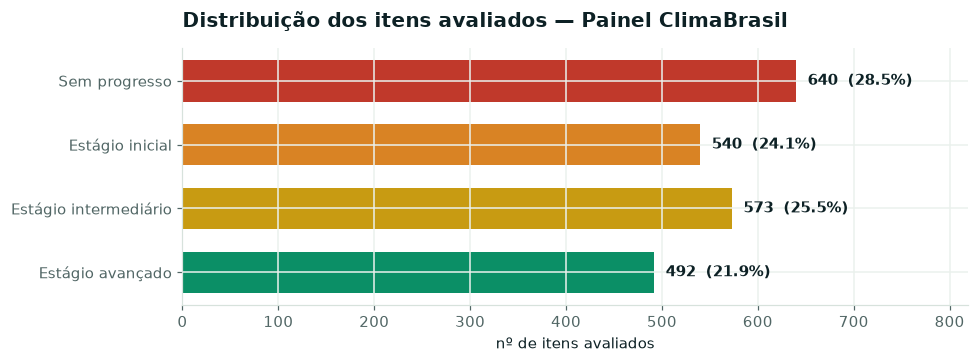

In [6]:
dist = itens.score_text.value_counts().reindex(ESCALA)
pct  = dist / dist.sum() * 100

resumo = pd.DataFrame({"itens": dist, "%": pct.round(1)})
print(resumo.to_string())
print()
print(f">>> {dist['Sem progresso']:,} itens ({pct['Sem progresso']:.1f}%) não têm nenhuma ação demonstrada.")
print(f">>> 'Sem progresso' é a categoria mais frequente de toda a avaliação nacional.")

fig, ax = plt.subplots(figsize=(9, 3.4))
cores = [VERMELHO, "#D98324", AMBAR, VERDE]
barras = ax.barh(ESCALA, dist.values, color=cores, height=.65)
for b, v, p in zip(barras, dist.values, pct.values):
    ax.text(v + 12, b.get_y() + b.get_height()/2, f"{v:,}  ({p:.1f}%)",
            va="center", fontsize=10, fontweight="bold", color=TINTA)
ax.set_xlim(0, dist.max()*1.28)
ax.set_title("Distribuição dos itens avaliados — Painel ClimaBrasil",
             fontsize=13, fontweight="bold", pad=14, loc="left")
ax.set_xlabel("nº de itens avaliados")
ax.invert_yaxis()
plt.tight_layout(); plt.show()

---
## 3. Qual eixo trava o país

O ClimateScanner organiza a avaliação em três eixos. Se a tese do projeto — *prevenir custa
menos que remediar* — estiver certa, esperamos encontrar a maior fragilidade justamente
no eixo que paga a prevenção.

                    lacunas  avaliados  taxa_pct
axis_name                                       
Financiamento           187        456      41.0
Políticas públicas      264        857      30.8
Governança              189        932      20.3

>>> Financiamento é o eixo mais frágil: 41.0% dos requisitos sem qualquer ação.


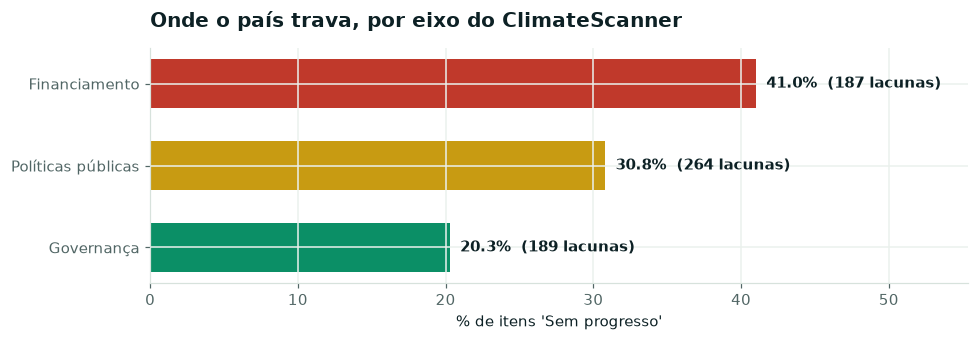

In [7]:
itens["lacuna"] = itens.score_text == "Sem progresso"

eixo = (itens.groupby("axis_name").lacuna
        .agg(lacunas="sum", avaliados="count", taxa="mean")
        .sort_values("taxa", ascending=False))
eixo["taxa_pct"] = (eixo.taxa*100).round(1)
print(eixo[["lacunas", "avaliados", "taxa_pct"]].to_string())
print()
pior = eixo.index[0]
print(f">>> {pior} é o eixo mais frágil: {eixo.loc[pior,'taxa_pct']}% dos requisitos sem qualquer ação.")

fig, ax = plt.subplots(figsize=(9, 3.2))
c = [VERMELHO if t > .35 else (AMBAR if t > .25 else VERDE) for t in eixo.taxa]
b = ax.barh(eixo.index, eixo.taxa*100, color=c, height=.6)
for bb, t, n in zip(b, eixo.taxa*100, eixo.lacunas):
    ax.text(t+.7, bb.get_y()+bb.get_height()/2, f"{t:.1f}%  ({n} lacunas)",
            va="center", fontweight="bold", color=TINTA)
ax.set_xlim(0, eixo.taxa.max()*100*1.35)
ax.set_xlabel("% de itens 'Sem progresso'")
ax.set_title("Onde o país trava, por eixo do ClimateScanner",
             fontsize=13, fontweight="bold", pad=14, loc="left")
ax.invert_yaxis()
plt.tight_layout(); plt.show()

**Confirmação da tese.** O eixo **Financiamento** é o mais frágil do país. Não é falta de
diagnóstico nem de discurso: é falta de dinheiro alocado, captado e executado. É precisamente
o gargalo que a literatura de redução de risco descreve — governos gastam na resposta,
não na prevenção.

---
## 4. Os componentes que evitam mortes são os mais falhos

Cada eixo se divide em componentes (G1–G7, P1–P5, F1–F3). Os nomes e definições abaixo
**não são nossos**: vêm da metodologia oficial publicada do Painel ClimaBrasil
(`painel-climabrasil-metodologia-secom.pdf`, disponível em climatescanner.org).

Isso importa muito. A metodologia documenta, para cada componente, **a base legal que o
sustenta**. Ou seja: uma lacuna não é falha contra uma boa prática — é falha contra uma
norma. Dois componentes são a linha de frente entre um evento extremo e uma tragédia:

- **P2 — Estratégias de adaptação** (Acordo de Paris; Lei de Acesso à Informação)
- **P5 — Defesa civil e risco de desastre** (Marco de Sendai; **Lei 12.608/2012**, a
  Política Nacional de Proteção e Defesa Civil)

In [8]:
# Nomenclatura OFICIAL, extraída da metodologia publicada do Painel ClimaBrasil
# (climatescanner.org → painel-climabrasil-metodologia-secom.pdf).
TEMAS = json.loads(Path("dados/componentes-oficiais.json").read_text(encoding="utf-8"))
TEMAS = {c: v["nome"] for c, v in TEMAS.items()}

# Base legal de cada componente, também da metodologia oficial. É o que permite
# dizer não apenas "faltou", mas "faltou contra qual norma".
LEIS = json.loads(Path("dados/referencias-legais.json").read_text(encoding="utf-8"))

for c in ["P5", "P2", "F3"]:
    print(f"{c} · {TEMAS[c]}")
    for ref in LEIS[c][:3]:
        print(f"      └ {ref[:88]}")

comp = (itens.groupby(["axis_name", "component_identifier"]).lacuna
        .agg(lacunas="sum", avaliados="count", taxa="mean").reset_index())
comp["tema"] = comp.component_identifier.map(TEMAS)
comp["taxa_pct"] = (comp.taxa*100).round(1)
comp = comp.sort_values("taxa", ascending=False)

print(comp[["component_identifier", "tema", "axis_name", "lacunas", "avaliados", "taxa_pct"]]
      .head(10).to_string(index=False))

P5 · Defesa civil e risco de desastre
      └ Acordo de Paris, artigo 8
      └ Marco de Sendai para redução de riscos de desastres 2015-2030, Organização das Nações Un
      └ Decisão 2/CMA.2, de 2019 (institui o Mecanismo Internacional de Varsóvia para perdas e d
P2 · Estratégias de adaptação
      └ Acordo de Paris
      └ Referencial para Avaliação da Governança do Centro de Governo (TCU)
      └ The Role of the Center of Government: a Literature Review (BID)
F3 · Mobilização de investimentos privados
      └ Lei Nº 12.187/2009, que Institui a Política Nacional sobre Mudança do Clima - PNMC e dá 
      └ Lei complementar Nº 140/2011 que ﬁxa normas relativas à proteção das paisagens naturais 
      └ Crédito e mercado de carbono
component_identifier                                  tema          axis_name  lacunas  avaliados  taxa_pct
                  F3 Mobilização de investimentos privados      Financiamento       56        100      56.0
                  P2              Estratég

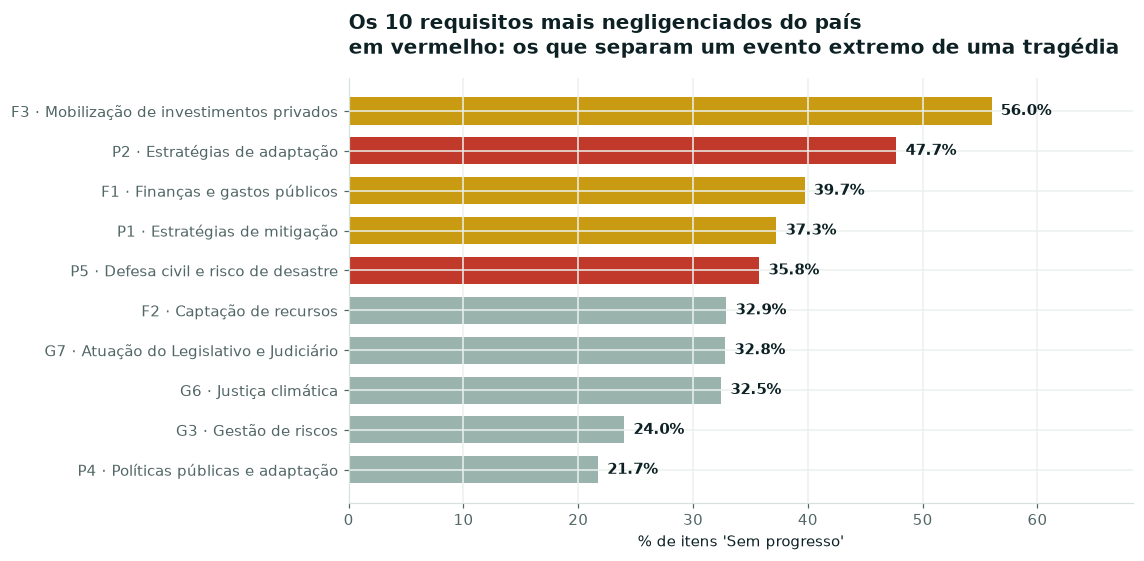

P2 · Estratégias de adaptação                47.7% sem progresso  (73/153)
P5 · Defesa civil e risco de desastre        35.8% sem progresso  (54/151)
F3 · Mobilização de investimentos privados   56.0% sem progresso  (56/100)


In [9]:
top = comp.head(10).iloc[::-1]
rot = [f"{r.component_identifier} · {r.tema}" for _, r in top.iterrows()]
critico = {"P2", "P5"}            # componentes que salvam vidas
cores = [VERMELHO if r.component_identifier in critico else
         (AMBAR if r.taxa > .35 else "#9BB3AD") for _, r in top.iterrows()]

fig, ax = plt.subplots(figsize=(10.5, 5.2))
b = ax.barh(rot, top.taxa*100, color=cores, height=.68)
for bb, t in zip(b, top.taxa*100):
    ax.text(t+.8, bb.get_y()+bb.get_height()/2, f"{t:.1f}%",
            va="center", fontweight="bold", color=TINTA)
ax.set_xlim(0, top.taxa.max()*100*1.22)
ax.set_xlabel("% de itens 'Sem progresso'")
ax.set_title("Os 10 requisitos mais negligenciados do país\n"
             "em vermelho: os que separam um evento extremo de uma tragédia",
             fontsize=13, fontweight="bold", pad=16, loc="left")
plt.tight_layout(); plt.show()

for c in ["P2", "P5", "F3"]:
    r = comp[comp.component_identifier == c].iloc[0]
    print(f"{c} · {r.tema:<38} {r.taxa_pct:>5}% sem progresso  ({r.lacunas}/{r.avaliados})")

---
## 5. Quantos brasileiros isso afeta

Um percentual não comove ninguém. Vamos converter lacuna em **gente**, cruzando o CSV do
TCU com a estimativa populacional do IBGE — a mesma fonte que o backend do projeto já
consome em produção.

> **Definição usada:** consideramos uma pessoa *exposta* quando o **governo do seu estado**
> apresenta ao menos um requisito "Sem progresso" no componente analisado. É uma medida de
> **lacuna de governança**, não de risco físico — e é assim que ela deve ser comunicada.

In [10]:
def baixar_populacao():
    # Estimativa populacional por UF e municipio (IBGE/SIDRA, tabela 6579)
    def get(url):
        req = urllib.request.Request(url, headers={"User-Agent": "climaton/1.0",
                                                   "Accept-Encoding": "gzip"})
        with urllib.request.urlopen(req, timeout=90) as r:
            raw = r.read()
            if raw[:2] == b"\x1f\x8b":
                raw = gzip.decompress(raw)
        return json.loads(raw.decode("utf-8"))

    def extrair(d):
        out = {}
        for s in d[0]["resultados"][0]["series"]:
            v = list(s["serie"].values())[0]
            if v not in ("...", "-", "..", "", None):
                try:
                    out[int(s["localidade"]["id"])] = int(v)
                except ValueError:
                    pass
        return out

    base = "https://servicodados.ibge.gov.br/api/v3/agregados/6579/periodos/2021/variaveis/9324?localidades="
    return {**extrair(get(base + "N3[all]")), **extrair(get(base + "N6[all]"))}

CACHE = Path("dados/populacao_ibge_2021.json")
try:
    pop = baixar_populacao()
    CACHE.parent.mkdir(parents=True, exist_ok=True)
    CACHE.write_text(json.dumps({str(k): v for k, v in pop.items()}), encoding="utf-8")
    print("População obtida na API do IBGE.")
except Exception as e:
    print(f"API indisponível ({type(e).__name__}); usando cópia local.")
    pop = {int(k): v for k, v in json.loads(CACHE.read_text(encoding="utf-8")).items()}

print(f"Localidades carregadas: {len(pop):,}")
itens["populacao"] = itens.entity_id.map(lambda x: pop.get(int(x)) if pd.notna(x) else np.nan)

População obtida na API do IBGE.
Localidades carregadas: 5,597


In [11]:
estados = itens[itens.entity_type == "Estado"]

linhas = []
for c in ["P2", "P5", "F1", "F3"]:
    sub  = estados[estados.component_identifier == c]
    ente = sub.groupby(["entity_name", "populacao"]).lacuna.max().reset_index()
    falha = ente[ente.lacuna]
    linhas.append({
        "comp": c,
        "tema": TEMAS[c],
        "estados_com_lacuna": f"{len(falha)}/{len(ente)}",
        "populacao_exposta": int(falha.populacao.sum()),
    })

exp = pd.DataFrame(linhas).sort_values("populacao_exposta", ascending=False)
exp["milhoes"] = (exp.populacao_exposta/1e6).round(1)
print(exp[["comp", "tema", "estados_com_lacuna", "milhoes"]].to_string(index=False))
print()
p2 = exp[exp.comp == "P2"].iloc[0]
p5 = exp[exp.comp == "P5"].iloc[0]
print(f">>> {p2.milhoes} milhões de brasileiros vivem em estados sem plena adaptação baseada em risco.")
print(f">>> {p5.milhoes} milhões vivem em estados com lacuna em Defesa Civil e contingência.")

comp                                  tema estados_com_lacuna  milhoes
  F3 Mobilização de investimentos privados              19/26    111.8
  P2              Estratégias de adaptação              20/26    103.4
  P5      Defesa civil e risco de desastre              13/26     73.9
  F1            Finanças e gastos públicos              18/26     70.5

>>> 103.4 milhões de brasileiros vivem em estados sem plena adaptação baseada em risco.
>>> 73.9 milhões vivem em estados com lacuna em Defesa Civil e contingência.


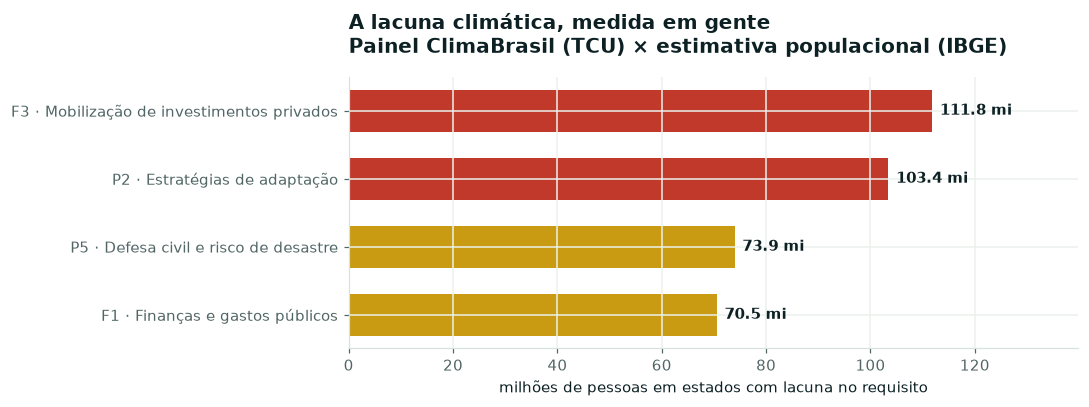

In [12]:
fig, ax = plt.subplots(figsize=(10, 3.8))
rot = [f"{r.comp} · {r.tema}" for _, r in exp.iloc[::-1].iterrows()]
val = exp.iloc[::-1].populacao_exposta/1e6
b = ax.barh(rot, val, color=[VERMELHO if v > 90 else AMBAR for v in val], height=.62)
for bb, v in zip(b, val):
    ax.text(v+1.5, bb.get_y()+bb.get_height()/2, f"{v:.1f} mi",
            va="center", fontweight="bold", color=TINTA)
ax.set_xlim(0, val.max()*1.25)
ax.set_xlabel("milhões de pessoas em estados com lacuna no requisito")
ax.set_title("A lacuna climática, medida em gente\n"
             "Painel ClimaBrasil (TCU) × estimativa populacional (IBGE)",
             fontsize=13, fontweight="bold", pad=16, loc="left")
plt.tight_layout(); plt.show()

---
## 6. O abismo federativo

A média nacional esconde o essencial. A distância entre o melhor e o pior ente é a
prova mais direta de que a política climática brasileira é desigual — e de que existe
um alvo óbvio para o controle externo.

In [13]:
rank = (itens.groupby(["entity_name", "entity_type"]).lacuna
        .agg(lacunas="sum", avaliados="count", taxa="mean")
        .reset_index().sort_values("taxa", ascending=False))
rank["taxa_pct"] = (rank.taxa*100).round(1)

print("PIORES — maior proporção de requisitos sem qualquer ação")
print(rank.head(8)[["entity_name", "entity_type", "lacunas", "avaliados", "taxa_pct"]].to_string(index=False))
print("\nMELHORES")
print(rank.tail(6)[["entity_name", "entity_type", "lacunas", "avaliados", "taxa_pct"]].to_string(index=False))
print()
print(f">>> Amplitude: de {rank.taxa_pct.max()}% ({rank.iloc[0].entity_name}) "
      f"a {rank.taxa_pct.min()}% ({rank.iloc[-1].entity_name}).")

PIORES — maior proporção de requisitos sem qualquer ação
entity_name entity_type  lacunas  avaliados  taxa_pct
  Boa Vista   Município       43         44      97.7
     Macapá   Município       42         44      95.5
    Vitória   Município       31         43      72.1
     Cuiabá   Município       30         44      68.2
    Roraima      Estado       30         45      66.7
    Paraíba      Estado       26         45      57.8
     Maceió   Município       25         44      56.8
Porto Velho   Município       21         44      47.7

MELHORES
      entity_name entity_type  lacunas  avaliados  taxa_pct
     Porto Alegre   Município        2         43       4.7
             Acre      Estado        2         45       4.4
Rio Grande do Sul      Estado        2         45       4.4
     Minas Gerais      Estado        0         45       0.0
   Rio de Janeiro   Município        0         42       0.0
        São Paulo      Estado        0         45       0.0

>>> Amplitude: de 97.7% (B

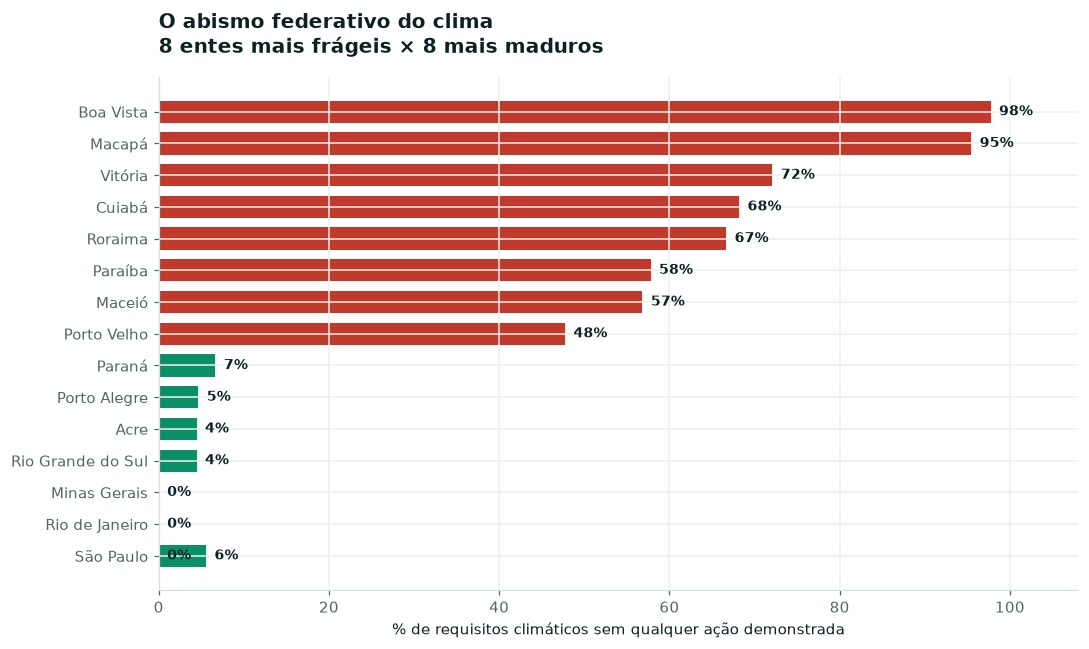

In [14]:
extremos = pd.concat([rank.head(8), rank.tail(8)]).iloc[::-1]
cores = [VERDE if t < .10 else (AMBAR if t < .45 else VERMELHO) for t in extremos.taxa]

fig, ax = plt.subplots(figsize=(10, 6))
rot = [f"{r.entity_name}" for _, r in extremos.iterrows()]
b = ax.barh(rot, extremos.taxa*100, color=cores, height=.7)
for bb, t in zip(b, extremos.taxa*100):
    ax.text(t+1, bb.get_y()+bb.get_height()/2, f"{t:.0f}%",
            va="center", fontweight="bold", fontsize=9, color=TINTA)
ax.set_xlim(0, 108)
ax.set_xlabel("% de requisitos climáticos sem qualquer ação demonstrada")
ax.set_title("O abismo federativo do clima\n"
             "8 entes mais frágeis × 8 mais maduros",
             fontsize=13, fontweight="bold", pad=16, loc="left")
plt.tight_layout(); plt.show()

Vale olhar para **quem** está no topo dessa lista: capitais amazônicas, com altíssima
exposição a evento extremo e quase nenhuma estrutura de governança climática. É exatamente
onde a diferença entre prevenir e remediar custa vidas.

---
## 7. Caso-âncora: Rio Grande do Sul

Em maio de 2024 o Rio Grande do Sul viveu a maior catástrofe climática da história recente
do país — perdas estimadas em **US$ 17,8 bilhões**, cerca de 0,76% do PIB brasileiro
(Banco Mundial).

A pergunta honesta não é *"o dado previu a enchente?"* — a avaliação é **posterior** ao
desastre. A pergunta é mais dura:

> **Depois da maior tragédia climática do estado, o que a avaliação técnica ainda encontrou?**

In [15]:
rs = df[df.entity_name == "Rio Grande do Sul"]
print(f"Data da avaliação do RS: {rs.assessment_completion_dt.iloc[0][:10]}")
print("(a enchente ocorreu em maio de 2024 — a avaliação é POSTERIOR ao desastre)")
print()

rs_itens = rs[rs.score_text.isin(ESCALA)]
print("Distribuição do RS:")
print(rs_itens.score_text.value_counts().reindex(ESCALA).to_string())
print()
print("Requisitos ainda 'Sem progresso' após a catástrofe:")
for _, r in rs_itens[rs_itens.score_text == "Sem progresso"].iterrows():
    print(f"  · {r.component_identifier}{r.item_identifier} — {TEMAS.get(r.component_identifier)} ({r.axis_name})")

Data da avaliação do RS: 2025-09-18
(a enchente ocorreu em maio de 2024 — a avaliação é POSTERIOR ao desastre)

Distribuição do RS:
score_text
Sem progresso             2
Estágio inicial          13
Estágio intermediário    20
Estágio avançado         10

Requisitos ainda 'Sem progresso' após a catástrofe:
  · F3B — Mobilização de investimentos privados (Financiamento)
  · P2B — Estratégias de adaptação (Políticas públicas)


In [16]:
p2b = rs[(rs.component_identifier == "P2") & (rs.item_identifier == "B")].iloc[0]
print("PARECER TÉCNICO — RS, componente P2B (monitoramento da adaptação)")
print(f"Avaliação: {p2b.score_text}")
print("=" * 92)
print(p2b.assessment_comment)

PARECER TÉCNICO — RS, componente P2B (monitoramento da adaptação)
Avaliação: Sem progresso
A estratégia estadual de adaptação prevista no ProClima2050 reconhece a importância do monitoramento contínuo e da avaliação periódica como fundamentos para a gestão climática. No entanto, não há especificação clara de mecanismos, indicadores ou metodologias para o acompanhamento das ações de adaptação, nem plano de avaliação integrado ao cronograma de implementação. Tampouco existem relatórios públicos de monitoramento, frequência definida ou uso documentado dos resultados para revisão das estratégias. A plataforma EstimaGás, por exemplo, tem foco em resíduos e mitigação, e não abrange aspectos de adaptação.
Diante da ausência de instrumentos específicos, frequência regular e ajustes estratégicos com base em evidências, este item é classificado como em estágio inicial.


### Como esta evidência deve ser lida — e comunicada

O RS **tem** uma estratégia de adaptação (ProClima2050). O que a avaliação apontou, mais de
um ano depois da enchente, foi a ausência de **monitoramento**: sem indicadores definidos,
sem relatórios públicos de acompanhamento, sem formalização legal por decreto ou lei.

> ✅ **Afirmação defensável:** *"Dezesseis meses após a maior catástrofe climática de sua
> história, a estratégia de adaptação do RS ainda não possuía indicadores de monitoramento,
> relatórios públicos de progresso nem formalização legal — segundo avaliação técnica de
> tribunal de contas."*
>
> ❌ **Afirmação que destruiria nossa credibilidade:** *"O RS não tinha plano de adaptação"*
> ou *"o dado previu a enchente"*. Ambas são falsas, e a banca do TCU sabe disso.

Esse é, em uma frase, o valor do produto: transformar um parecer técnico soterrado num CSV
em **uma pergunta que exige resposta de um gestor** — sem exagerar um milímetro além do que
o dado sustenta.

---
## 8. Síntese: a matéria-prima de um dossiê

Fechamos com o inventário do que o CSV entrega para cada ente — que é exatamente o índice
do documento que o produto gera.

In [17]:
def matriz_do_ente(nome):
    e = itens[itens.entity_name == nome]
    if e.empty:
        return f"Ente não encontrado: {nome}"
    lac = e[e.lacuna]
    print(f"╔═ DOSSIÊ — {nome} ({e.entity_type.iloc[0]})")
    print(f"║  Fonte: Painel ClimaBrasil · {versao} · snapshot {snapshot}")
    print(f"║  Requisitos avaliados : {len(e)}")
    print(f"║  Lacunas encontradas  : {len(lac)}  ({len(lac)/len(e)*100:.1f}%)")
    pp = e.populacao.dropna()
    if len(pp):
        print(f"║  População (IBGE)     : {int(pp.iloc[0]):,}".replace(",", "."))
    print("╠═ ACHADOS")
    for _, r in lac.iterrows():
        c = r.component_identifier
        print(f"║")
        print(f"║   [{c}{r.item_identifier}] {TEMAS.get(c)}")
        base = LEIS.get(c, [])
        if base:
            print(f"║        base normativa: {base[0][:88]}")
        just = " ".join(str(r.assessment_comment).split())
        print(f"║        o que a auditoria apurou: {just[:130]}...")
    print("╚" + "═"*70)

matriz_do_ente("Boa Vista")

╔═ DOSSIÊ — Boa Vista (Município)
║  Fonte: Painel ClimaBrasil · Versão de Avaliação 2025 · snapshot 2025-09-12
║  Requisitos avaliados : 44
║  Lacunas encontradas  : 43  (97.7%)
║  População (IBGE)     : 436.591
╠═ ACHADOS
║
║   [F1A] Finanças e gastos públicos
║        base normativa: Lei nº 14.133/2021. Lei de Licitações e Contratos Administrativos
║        o que a auditoria apurou: Não há previsão específica no PPA ou leis orçamentárias do município de Boa Vista de ações ou recursos para o enfrentamento das mu...
║
║   [F1B] Finanças e gastos públicos
║        base normativa: Lei nº 14.133/2021. Lei de Licitações e Contratos Administrativos
║        o que a auditoria apurou: O município de Boa Vista não adota nenhuma metodologia de identificação dos gastos climáticos em seu orçamento....
║
║   [F1C] Finanças e gastos públicos
║        base normativa: Lei nº 14.133/2021. Lei de Licitações e Contratos Administrativos
║        o que a auditoria apurou: Não existem mecanismos formais n

Repare no formato acima: **requisito → norma que o sustenta → o que a auditoria apurou.**
Essa é exatamente a estrutura de um achado de auditoria — e ela sai inteira do dado público,
sem que precisemos acrescentar uma linha de opinião.

In [18]:
linhas_sintese = [
    "=" * 74,
    f"  SINTESE DA ANALISE - Painel ClimaBrasil ({versao})",
    "=" * 74,
    f"  Entes avaliados ................. {itens.entity_name.nunique():>10}",
    f"  Requisitos analisados ........... {len(itens):>10,}",
    f"  Pareceres tecnicos disponiveis .. {itens.assessment_comment.notna().sum():>10,}   ({itens.assessment_comment.notna().mean()*100:.0f}% de cobertura)",
    f"  Lacunas 'Sem progresso' ......... {int(itens.lacuna.sum()):>10,}   ({itens.lacuna.mean()*100:.1f}%)",
    f"  Eixo mais fragil ................ {eixo.index[0]:>10}   ({eixo.iloc[0]['taxa_pct']}%)",
    f"  Requisito mais negligenciado .... {comp.iloc[0].component_identifier:>10}   {comp.iloc[0].tema}",
    f"  Populacao exposta (adaptacao) ... {p2.milhoes:>9} mi",
    f"  Populacao exposta (def. civil) .. {p5.milhoes:>9} mi",
    "=" * 74,
    "  CONCLUSAO",
    "  A evidencia para cobrar acao climatica no Brasil ja existe, e publica",
    "  e foi escrita por tribunais de contas. Nao falta dado - falta entrega-lo",
    "  no formato que um cidadao leva a uma reuniao e um auditor transforma",
    "  em achado.",
    "=" * 74,
]
print(chr(10).join(linhas_sintese))

  SINTESE DA ANALISE - Painel ClimaBrasil (Versão de Avaliação 2025)
  Entes avaliados .................         49
  Requisitos analisados ...........      2,245
  Pareceres tecnicos disponiveis ..      2,245   (100% de cobertura)
  Lacunas 'Sem progresso' .........        640   (28.5%)
  Eixo mais fragil ................ Financiamento   (41.0%)
  Requisito mais negligenciado ....         F3   Mobilização de investimentos privados
  Populacao exposta (adaptacao) ...     103.4 mi
  Populacao exposta (def. civil) ..      73.9 mi
  CONCLUSAO
  A evidencia para cobrar acao climatica no Brasil ja existe, e publica
  e foi escrita por tribunais de contas. Nao falta dado - falta entrega-lo
  no formato que um cidadao leva a uma reuniao e um auditor transforma
  em achado.


---
## Nota metodológica (leia antes de citar qualquer número daqui)

1. **Fonte primária:** `pcb-raw-data.csv`, Painel ClimaBrasil / TCU, metodologia
   ClimateScanner-INTOSAI. Versão e data do snapshot impressas na célula 0.
   Os dados brutos e a metodologia são publicados em
   [climatescanner.org/pt/downloads-2](https://climatescanner.org/pt/downloads-2/).
1b. **Nomes dos componentes e base legal** vêm da metodologia oficial
   (`painel-climabrasil-metodologia-secom.pdf`), não de inferência nossa.
2. **"Sem progresso"** é a categoria da própria escala oficial — não é um julgamento nosso.
   Itens "Não avaliado" e "Não se aplica" foram excluídos dos percentuais.
3. **População exposta** mede *lacuna de governança*, não risco físico. A frase correta é
   "vive em um estado cujo governo apresenta lacuna no requisito X" — nunca
   "está em risco de morrer".
4. **Não há inferência causal** neste notebook. Nenhuma correlação aqui prova que uma
   lacuna causou um desastre. O caso do RS é apresentado como cronologia documentada,
   não como causalidade.
5. **O arquivo `backend/data/pcb-raw-data-2026.csv` é sintético** — foi gerado por
   `scripts/gerar-csv-ano.js`, que apenas troca o ano do snapshot para testar a tela de
   evolução. **Ele não contém dados reais de 2026 e não pode ser usado como evidência.**

*Reprodutibilidade: `python analise/gerar_notebook.py` regenera este notebook; todas as
células rodam apenas com pandas, numpy e matplotlib, mais acesso à API do IBGE (com cache
local em `analise/dados/`).*